In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display
import warnings
warnings.filterwarnings("ignore") 


#Fenêtre de hamming
def hamming(T): return 0.54-0.46*np.cos(2*np.pi*np.arange(T)/(T-1))

#Calcul du spectre amplitude et phase du signal data, taille de la fenetre=T, pas=p
#mettre pre=True dans l'appel pour activer la préaccentuation
#mettre ham=True pour activer le fenêtrage par hamming
#Tfft=taille de la fft, si > T le zéro padding sera activé(voir cours acoustique)
def spectrogram(data,fs,T=512,p=32,pre=False,ham=True,Tfft=None,norm=True):
    if Tfft is None: Tfft=T #si la taille de la fft n'est pas spécifiée prendre Tfft=T        
    if norm: data=(data-np.mean(data))/np.std(data) #normaliser le signal sur son écart type
    
    if pre: data[1:]-0.97*data[:-1]      #préaccentuation
    s=[data[i:i+T] for i in range(0,len(data)-T,p)] # fenêtrage
    if ham : s=s*hamming(T)          # multiplication par hamming            
    s=np.fft.fft(s,Tfft)                 #Transformée de Fourier
    s=s[:,:int(Tfft/2)]                  #couper le spectre en 2 pour éliminer l'effet mirroir
    
    #retourner les spectres d'amplitude et de phase
    return {"ampl": np.abs(s), "phase": np.angle(s), "fs":fs, "duree":len(data)/fs, "T": T, "p": p, "Tfft": Tfft}


#Cette fonction affiche un spectrogramme d'amplitude
def afficher(spec):
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax3 = ax1.twiny()
    freq=np.linspace(0, spec["fs"]/2, int(spec["Tfft"]/2)) #labels de l'axe des fréquences
    temps=np.linspace(0, spec["duree"], len(spec["ampl"])) #labels de l'axe du temps
    ax1.pcolormesh(temps, freq, np.log(spec["ampl"]+1).T, cmap='gray_r')  #afficher le spectre avec correction des axes
    ax1.set_ylabel('Fréquence (Hz)')
    ax1.set_xlabel('Temps (sec)')
    ax2.set_yticks(np.round(ax2.get_yticks()*int(spec["Tfft"]/2)))
    ax2.set_ylabel('Indices des colonnes dans la matrice spec')
    ax3.set_xticks(np.round(ax3.get_xticks()*len(spec["ampl"])))
    ax3.set_xlabel('Indices des lignes dans la matrice spec')
    plt.show()
    

#Retour à partir de l'amplitude et de la phase au signal temporel 
#Ne pas utiliser la préaccentuation si vous voulez utiliser cette fonction
def spec2wav(spec):
    p=spec["p"]; T=spec["T"]
    ne=(len(spec["ampl"])-1)*p+T  #estimation le nombre d'échantillons du signal
    signal=np.zeros(ne)  #initialiser le signal par des zéros 
    trams=np.zeros(ne)  #initialiser le nombre de trames par des zéros 
    
    temp=spec["ampl"]*np.exp(1j*spec["phase"]) #recombiner l'amplitude avec la phase (nombre complexe)
    temp=np.fft.ifft(temp, spec["Tfft"]) #retour au domaine temporel par une fft inverse
    temp=np.real(temp) #ne garder que la partie réelle
    
    for i in range(len(temp)): #fenêtrage inverse
        signal[i*p:i*p+T]+=temp[i,:T]
        trams[i*p:i*p+T]+=1

    return signal/trams, spec["fs"] #retourner le signal reconstitué et la fréquence d'échantillonnage

Chargement de : mots_bruit.wav
Freq échantillonnage: 8000 Hz, durée: 19.569875 sec


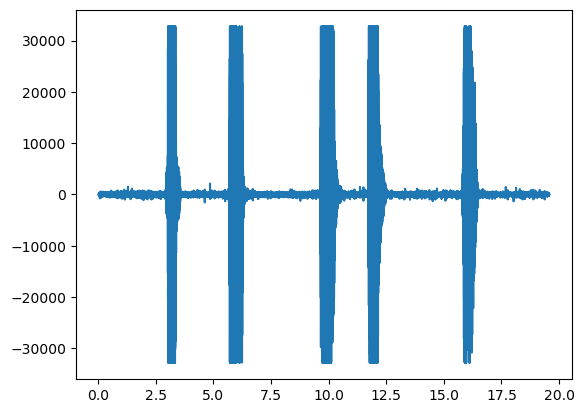

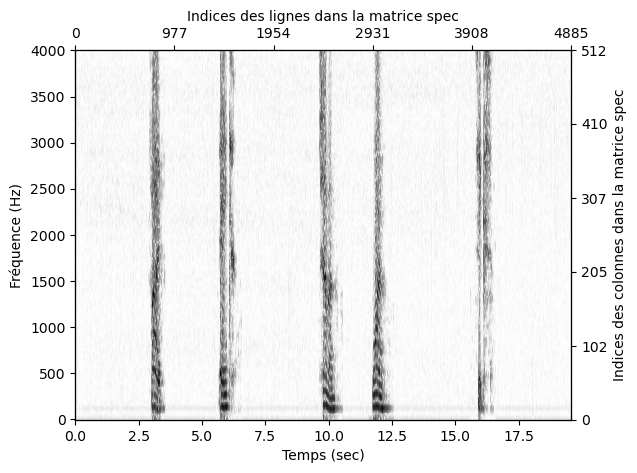

In [25]:
dataset_path="dataset\\dataset\\" #le chemin vers le dataset
filename="mots_bruit.wav" #le nom du fichier à charger

print('Chargement de :', filename)#chargement d'un fichier audio wav
fs, data = wavfile.read(dataset_path+filename) #fs: fréquence d'échantillonnage 

print('Freq échantillonnage:',fs,'Hz, durée:',len(data)/fs,'sec')
display(Audio(data,rate=fs))
plt.plot(np.arange(len(data))/fs,data); plt.show() #affichage du signal temporel

spec=spectrogram(data, fs, T=256, Tfft=1025) #calcul du spectrogramme 
afficher(spec) #affichage du spectrogramme

In [26]:
newdata, fs= spec2wav(spec)
display(Audio(newdata,rate=fs))

# filtre passe bas

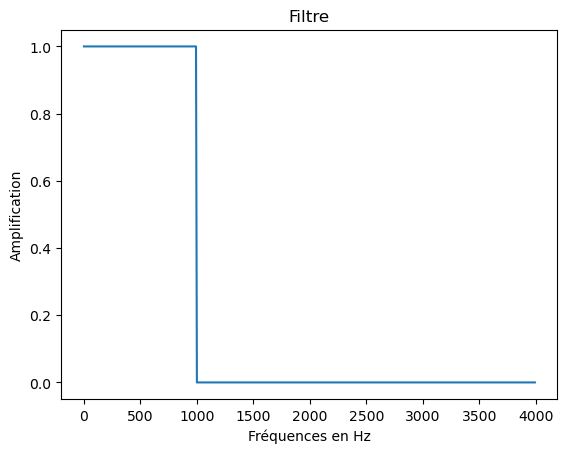

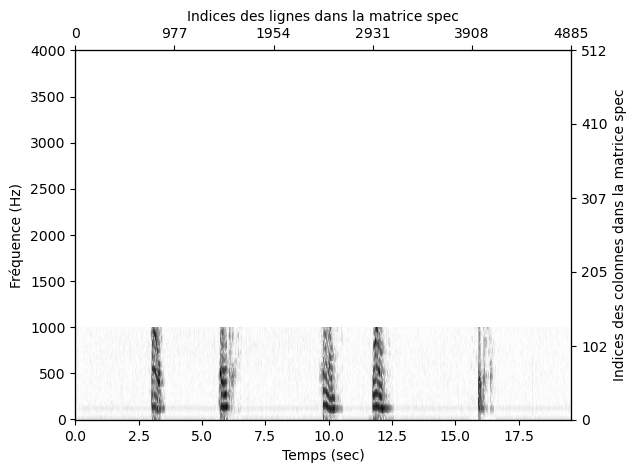

In [27]:
Tfft=1024

filtre=np.zeros(Tfft//2)
filtre[:128]=1  #annuler toutes les fréquences > 1000Hz
plt.plot(np.arange(Tfft//2)*fs/Tfft,filtre)
plt.title("Filtre")
plt.xlabel("Fréquences en Hz")
plt.ylabel("Amplification")
plt.show()

spec=spectrogram(data, fs, T=256, Tfft=Tfft) #calcul et affichage d'un spectrogramme avec fenêtre de hamming
spec["ampl"]=spec["ampl"]*filtre  
afficher(spec) #affichage du spectrogramme
newdata, fs= spec2wav(spec)  #retour au domaine temporel
display(Audio(newdata,rate=fs)) #écouter le résultat

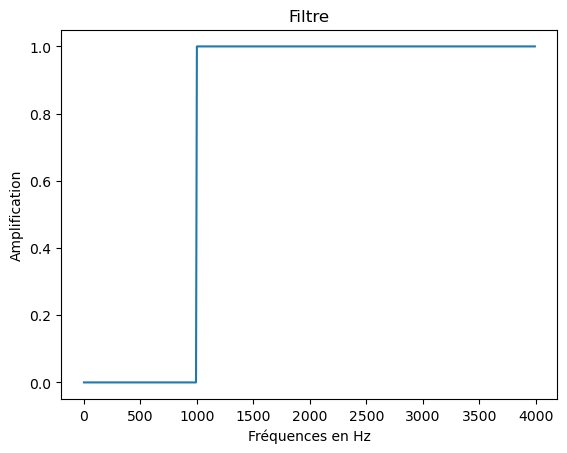

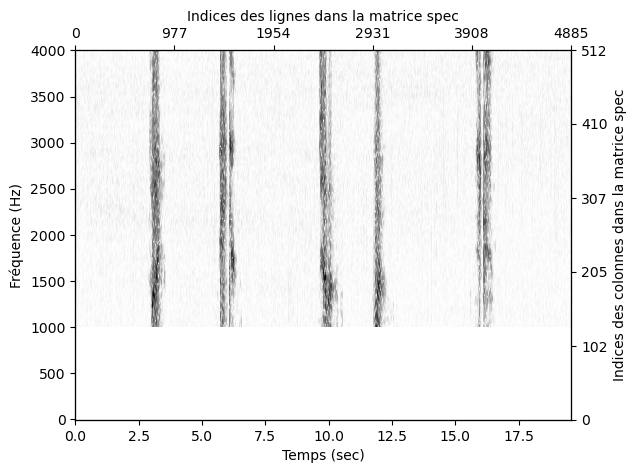

In [28]:
Tfft=1024

filtre=np.zeros(Tfft//2)
filtre[128:]=1  #annuler toutes les fréquences < 1000Hz
plt.plot(np.arange(Tfft//2)*fs/Tfft,filtre)
plt.title("Filtre")
plt.xlabel("Fréquences en Hz")
plt.ylabel("Amplification")
plt.show()

spec=spectrogram(data, fs, T=256, Tfft=Tfft) #calcul et affichage d'un spectrogramme avec fenêtre de hamming
spec["ampl"]=spec["ampl"]*filtre  
afficher(spec) #affichage du spectrogramme
newdata, fs= spec2wav(spec)  #retour au domaine temporel
display(Audio(newdata,rate=fs)) #écouter le résultat

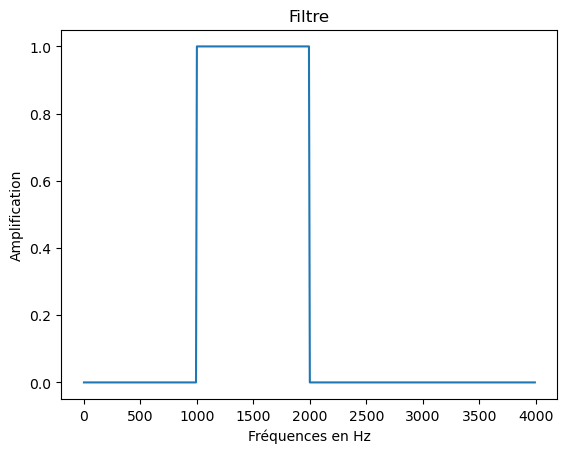

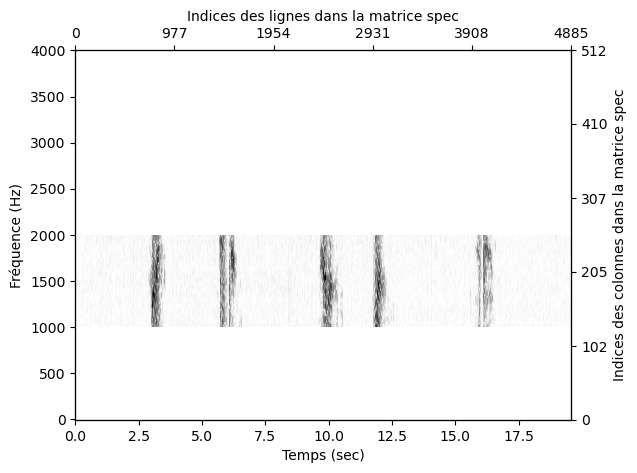

In [29]:
Tfft=1024

filtre=np.zeros(Tfft//2)
filtre[128:256]=1  #annuler toutes les fréquences < 1000Hz ou > 2000Hz
plt.plot(np.arange(Tfft//2)*fs/Tfft,filtre)
plt.title("Filtre")
plt.xlabel("Fréquences en Hz")
plt.ylabel("Amplification")
plt.show()

spec=spectrogram(data, fs, T=256, Tfft=Tfft) #calcul et affichage d'un spectrogramme avec fenêtre de hamming
spec["ampl"]=spec["ampl"]*filtre  
afficher(spec) #affichage du spectrogramme
newdata, fs= spec2wav(spec)  #retour au domaine temporel
display(Audio(newdata,rate=fs)) #écouter le résultat

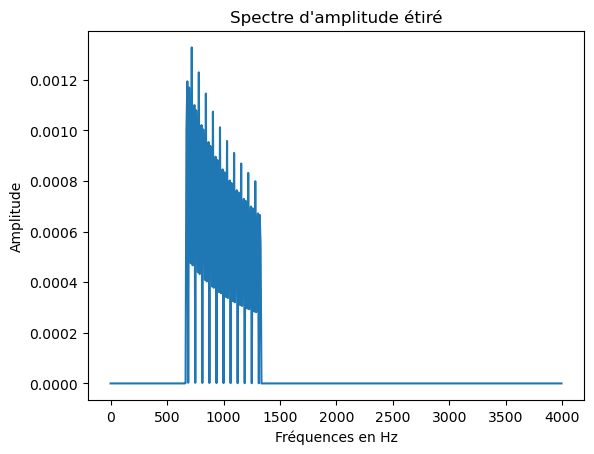

In [30]:
from scipy.interpolate import interp1d

# Etirer le spectre d'amplitude avec le facteur "a"  (new f0= f0*a)  
def interpolate(amp, a):
    n,m=amp.shape
    new_amp=np.zeros((n,m))
    
    for i in range(n):
        f=interp1d(np.arange(m), amp[i,:])
        new_x=np.arange(m)*a
        new_x[new_x>m-1]=m-1
        new_amp[i,:]=f(new_x)
    return new_amp  
interpolated = interpolate(spec["ampl"], 1.5)
plt.plot(np.arange(interpolated.shape[1])*fs/spec["Tfft"], interpolated[0,:])
plt.title("Spectre d'amplitude étiré")
plt.xlabel("Fréquences en Hz")
plt.ylabel("Amplitude")
plt.show()


## Filtrer Bruit

In [ ]:

def FilterNoise(data, T, p, Tfft=None):
    if Tfft is None:
        Tfft = T
    data = data.copy()
    data[1:] = data[1:] - 0.97 * data[:-1]  # préaccentuation
    s = [data[i:i+T] for i in range(0, len(data)-T, p)]  # fenêtrage
    s = np.array(s) * hamming(T)  # conversion + multiplication par hamming
    s = np.fft.fft(s, Tfft)
    s = np.abs(s)
    sqr = np.square(s)
    Energy = [np.sum(c) for c in sqr]
    print(Energy)
    mask = (Energy > threshold).astype(float)
    filtered_s = s [mask]
    threshold = np.mean(Energy)
    return filtered_s
FilterNoise(data,280, 32)

[0.0, 0.0, 1789157.8659700486, 17768403.729053043, 94648305.35742868, 291057629.6479491, 604883818.5125234, 1002485289.1573664, 1359639685.4856472, 1494145722.134421, 1423674058.5719676, 1451163380.4072723, 1692376882.1697838, 1871785474.0898218, 1717533153.0603595, 1367196698.442258, 1131353966.7573042, 1180222531.4670954, 1418197133.632463, 1568801579.9463706, 1454510715.5176175, 1215745025.0893612, 1107034975.903211, 1153598415.6078362, 1165965760.9838152, 1053846750.081405, 932493030.8082517, 942775805.8213189, 1069218040.5267913, 1172852573.241259, 1218219454.95539, 1254370601.3781147, 1294278010.429772, 1280953179.5122294, 1223085976.4927874, 1253705730.8830621, 1449153581.3900275, 1677447242.7974916, 1756741540.8462396, 1611214881.4619153, 1320347996.521522, 1104376156.9150014, 1148718069.8140974, 1343163204.3299308, 1430929897.572659, 1353362998.3448172, 1253648550.7031798, 1191958010.5965352, 1113494549.5539186, 1047637912.8875158, 1031503981.1532314, 1040138017.8124313, 10611

UnboundLocalError: cannot access local variable 'threshold' where it is not associated with a value